In [ ]:
from sentence_transformers import SentenceTransformer, util

import spacy

nlp = spacy.load("en_core_web_sm")

def sent_tokenize(text):
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]


model = SentenceTransformer('all-MiniLM-L6-v2')


def semantic_chunk(text, similarity_threshold=0.7, max_sentences_per_chunk=10):
    sentences = sent_tokenize(text)
    embeddings = model.encode(sentences, convert_to_tensor=True)

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        sim = util.cos_sim(embeddings[i - 1], embeddings[i])[0][0].item()
        print("Similarity:", sim,)

        # Start new chunk when topic changes (low similarity)
        if sim < similarity_threshold or len(current_chunk) >= max_sentences_per_chunk:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    # Add last chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks


# Example usage
text = """
Contextual advertising is a form of targeted advertising that appears on websites or other media,
such as content displayed in mobile browsers. The ads are selected and served by automated systems
based on the content being viewed by the user. Modern systems use machine learning to improve relevance.

In contrast, behavioral advertising relies on tracking user activity over time, across multiple websites,
to build a user profile. Contextual advertising does not require this — making it more privacy-friendly.

Computer vision can also be used in contextual ad placement by analyzing images and videos to detect
objects, logos, or scenes that indicate relevant advertising opportunities.
"""

chunks = semantic_chunk(text, similarity_threshold=0.8, max_sentences_per_chunk=10)
for i, c in enumerate(chunks):
    print(f"\n--- Chunk {i + 1} ---\n{c}\n")


Consecutive similarity scores: [0.13755609 0.28621203 0.00754127]


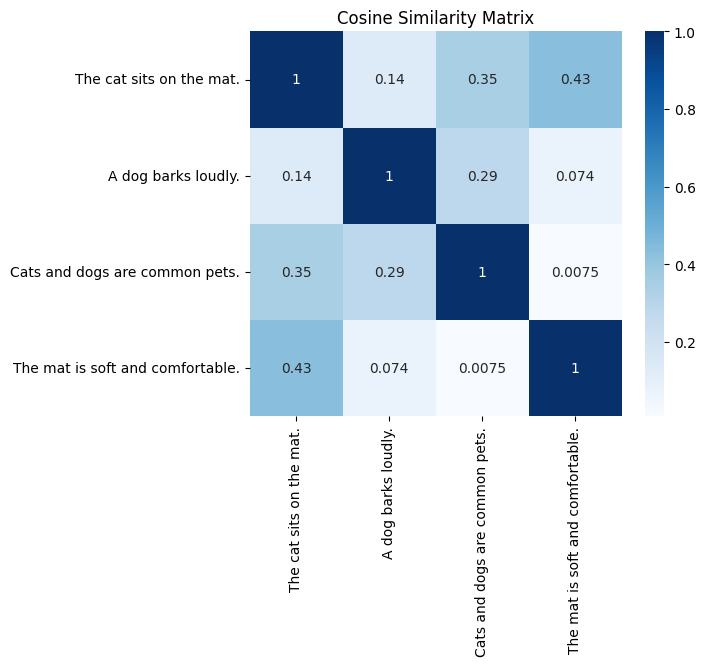

In [16]:
import numpy as np
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

# Example sentences
sentences = [
    "The cat sits on the mat.",
    "A dog barks loudly.",
    "Cats and dogs are common pets.",
    "The mat is soft and comfortable."
]

# Load model and get embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

# Cosine similarity matrix
cosim_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

# Cosine similarity between consecutive pairs (diagonal of offset matrix)
consecutive_sim = util.cos_sim(embeddings[:-1], embeddings[1:]).diag().cpu().numpy()
print("Consecutive similarity scores:", consecutive_sim)

# Plot confusion matrix (cosine similarity matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(cosim_matrix, annot=True, cmap="Blues", xticklabels=sentences, yticklabels=sentences)
plt.title("Cosine Similarity Matrix")
plt.show()

In [23]:
breakpoint_distance_threshold = np.percentile(consecutive_sim, 90)
print(breakpoint_distance_threshold)

0.25648084
